<a href="https://colab.research.google.com/github/4GeeksAcademy/retnarou-algorithm-optimization-project-machine-learning/blob/main/Forecasting_time_series.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

!pip install pmdarima
from pmdarima import auto_arima

from sklearn.metrics import mean_absolute_error, mean_squared_error

import joblib

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 16.3 MB/s eta 0:00:00


In [3]:
url = "https://breathecode.herokuapp.com/asset/internal-link?id=2546&path=sales.csv"

df = pd.read_csv(url)

df.head()

,date,sales
0,2022-09-03 17:10:08.079328,55.292157
1,2022-09-04 17:10:08.079328,53.803211
2,2022-09-05 17:10:08.079328,58.141693
3,2022-09-06 17:10:08.079328,64.530899
4,2022-09-07 17:10:08.079328,66.013633


In [4]:
print("Shape:", df.shape)
print("\nTipos de datos:")
print(df.dtypes)

print("\nValores nulos:")
print(df.isnull().sum())

df.head()

Shape: (366, 2)

Tipos de datos:
date      object
sales    float64
dtype: object

Valores nulos:
date     0
sales    0
dtype: int64


,date,sales
0,2022-09-03 17:10:08.079328,55.292157
1,2022-09-04 17:10:08.079328,53.803211
2,2022-09-05 17:10:08.079328,58.141693
3,2022-09-06 17:10:08.079328,64.530899
4,2022-09-07 17:10:08.079328,66.013633


In [5]:
df["date"] = pd.to_datetime(df["date"])

df = df.sort_values("date")

df = df.set_index("date")

sales_ts = df["sales"]

sales_ts.head()

,sales
date,
2022-09-03 17:10:08.079328,55.292157
2022-09-04 17:10:08.079328,53.803211
2022-09-05 17:10:08.079328,58.141693
2022-09-06 17:10:08.079328,64.530899
2022-09-07 17:10:08.079328,66.013633


In [6]:
sales_ts.index.to_series().diff().value_counts().head()

,count
date,
1 days,365


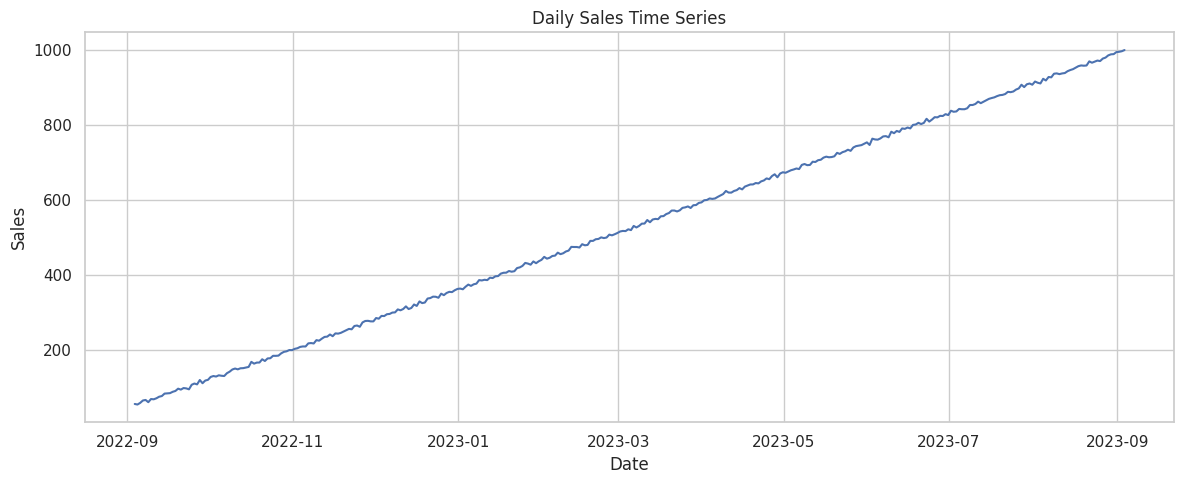

In [7]:
plt.figure(figsize=(12, 5))

sns.lineplot(x=sales_ts.index, y=sales_ts.values)

plt.title("Daily Sales Time Series")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

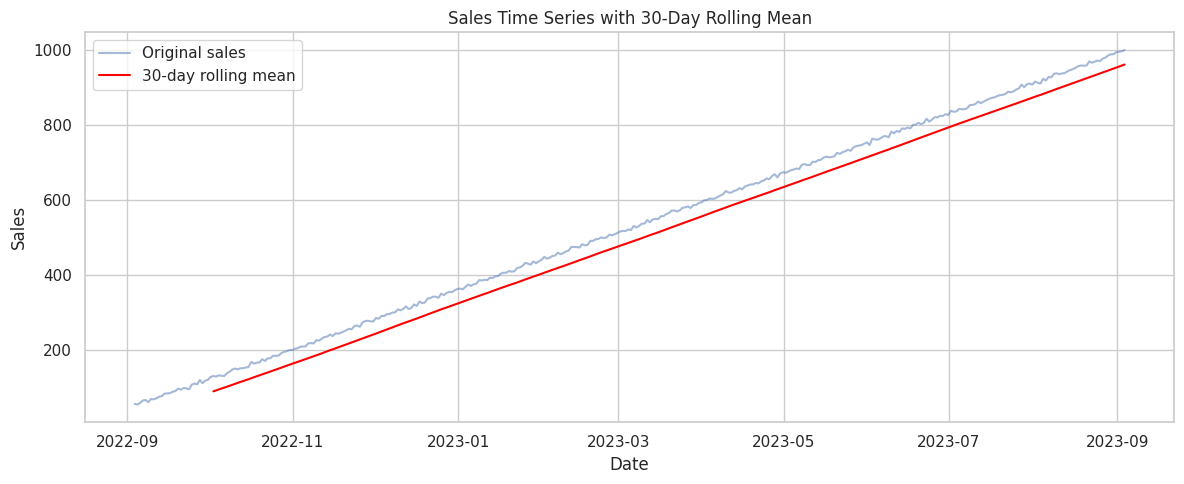

In [8]:
rolling_mean_30 = sales_ts.rolling(window=30).mean()

plt.figure(figsize=(12, 5))

sns.lineplot(x=sales_ts.index, y=sales_ts.values, label="Original sales", alpha=0.5)
sns.lineplot(x=rolling_mean_30.index, y=rolling_mean_30.values, label="30-day rolling mean", color="red")

plt.title("Sales Time Series with 30-Day Rolling Mean")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.show()

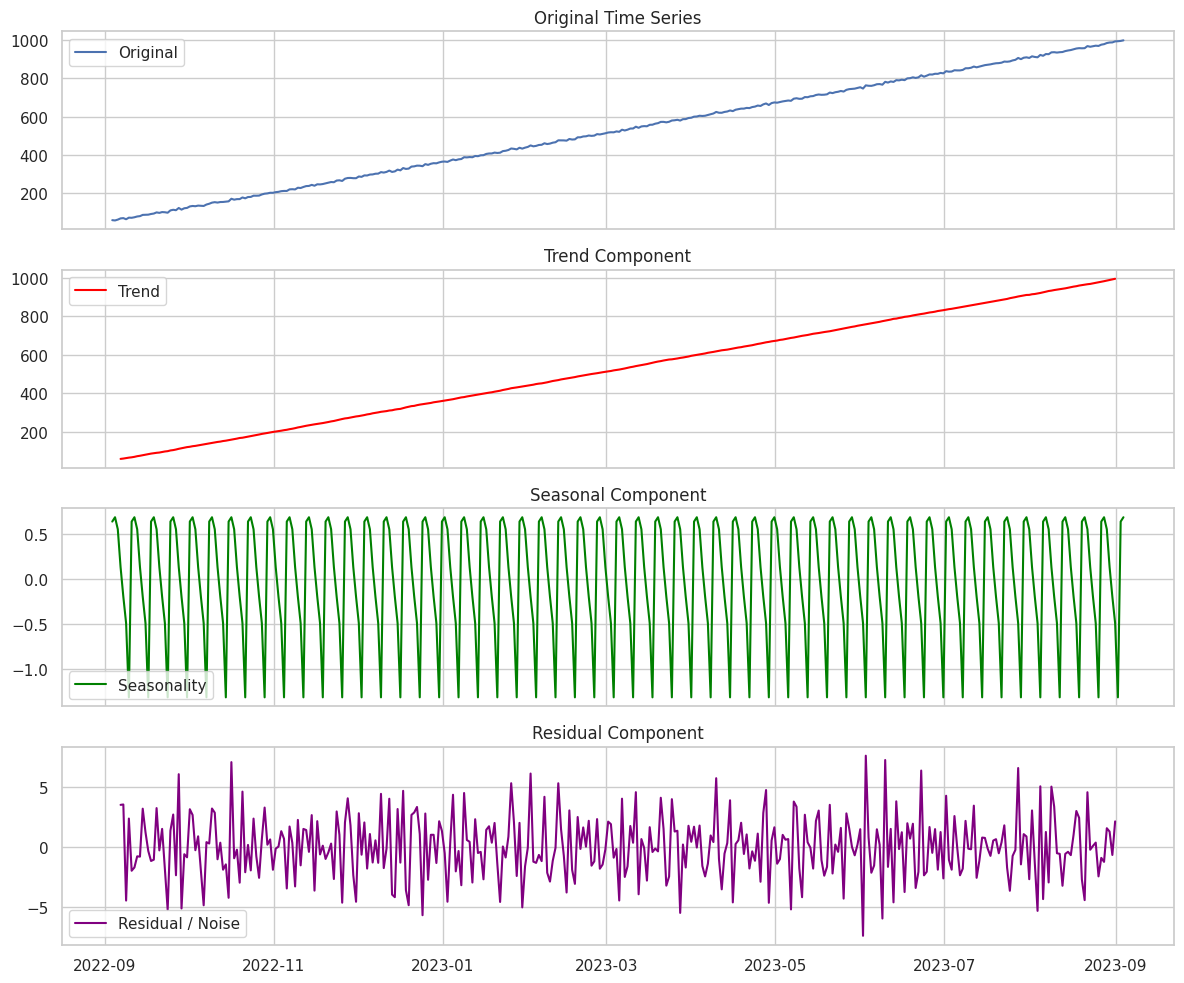

In [9]:
decomposition = seasonal_decompose(sales_ts, model="additive", period=7)

trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

axes[0].plot(sales_ts, label="Original")
axes[0].set_title("Original Time Series")
axes[0].legend()

axes[1].plot(trend, label="Trend", color="red")
axes[1].set_title("Trend Component")
axes[1].legend()

axes[2].plot(seasonal, label="Seasonality", color="green")
axes[2].set_title("Seasonal Component")
axes[2].legend()

axes[3].plot(residual, label="Residual / Noise", color="purple")
axes[3].set_title("Residual Component")
axes[3].legend()

plt.tight_layout()
plt.show()

In [10]:
def adf_test(series):
    """
    Runs the Augmented Dickey-Fuller test and returns the results
    in a readable format.
    """
    result = adfuller(series.dropna(), autolag="AIC")

    output = pd.Series(
        result[0:4],
        index=[
            "Test Statistic",
            "p-value",
            "Lags Used",
            "Number of Observations"
        ]
    )

    for key, value in result[4].items():
        output[f"Critical Value ({key})"] = value

    return output

adf_results = adf_test(sales_ts)
adf_results

,0
Test Statistic,0.545414
p-value,0.986190
Lags Used,13.000000
Number of Observations,352.000000
Critical Value (1%),-3.449065
Critical Value (5%),-2.869786
Critical Value (10%),-2.571163


In [11]:
p_value = adf_results["p-value"]

if p_value < 0.05:
    print("The series is likely stationary because the p-value is below 0.05.")
else:
    print("The series is likely non-stationary because the p-value is above 0.05.")

The series is likely non-stationary because the p-value is above 0.05.


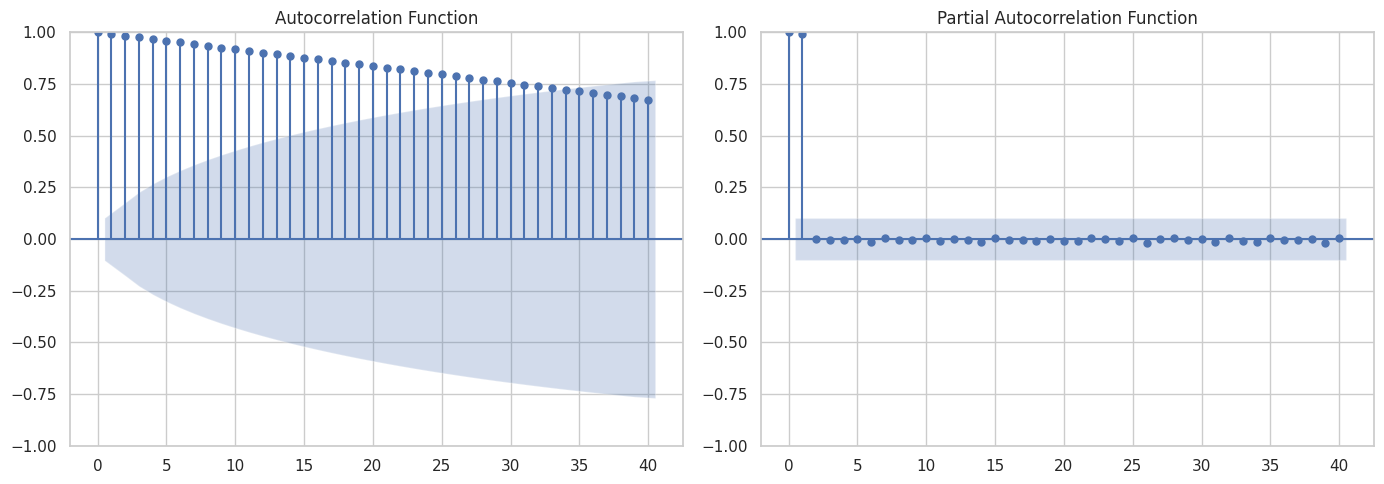

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(sales_ts, ax=axes[0], lags=40)
axes[0].set_title("Autocorrelation Function")

plot_pacf(sales_ts, ax=axes[1], lags=40)
axes[1].set_title("Partial Autocorrelation Function")

plt.tight_layout()
plt.show()

In [13]:
test_size = 60

train = sales_ts.iloc[:-test_size]
test = sales_ts.iloc[-test_size:]

print("Train size:", train.shape[0])
print("Test size:", test.shape[0])

Train size: 306
Test size: 60


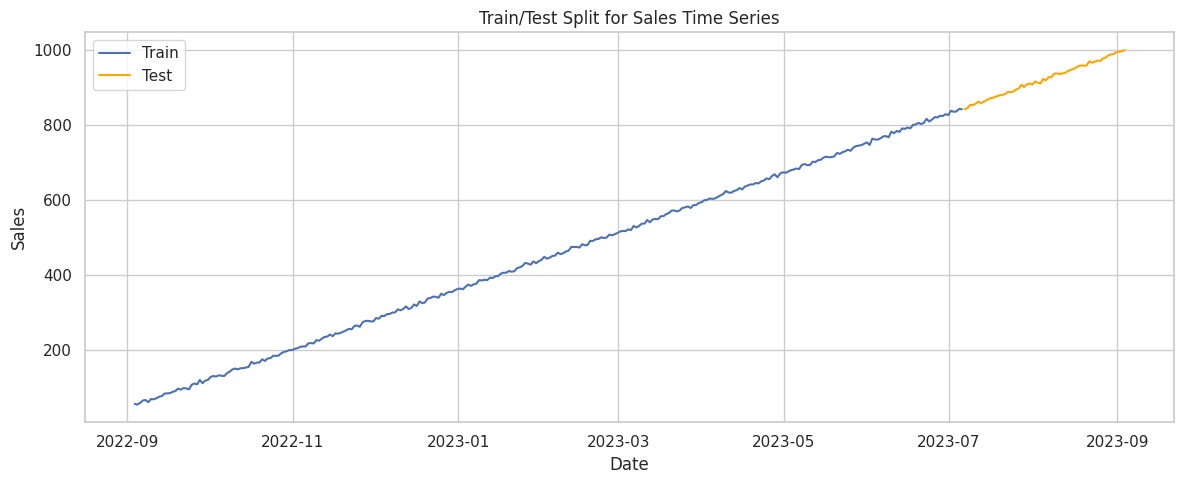

In [14]:
plt.figure(figsize=(12, 5))

sns.lineplot(x=train.index, y=train.values, label="Train")
sns.lineplot(x=test.index, y=test.values, label="Test", color="orange")

plt.title("Train/Test Split for Sales Time Series")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
arima_model = auto_arima(
    train,
    seasonal=False,
    trace=True,
    stepwise=True,
    suppress_warnings=True,
    error_action="ignore"
)

print(arima_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=1548.472, Time=3.35 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1762.723, Time=0.05 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1658.000, Time=0.17 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1546.075, Time=0.26 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1853.658, Time=0.04 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1545.060, Time=0.33 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=1546.949, Time=0.57 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=1548.908, Time=0.74 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=1544.960, Time=0.21 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=1546.916, Time=0.24 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=inf, Time=0.81 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=1818.018, Time=0.07 sec

Best model:  ARIMA(0,1,2)(0,0,0)[0] intercept
Total fit time: 6.906 seconds
                               SARIMAX Results                                
Dep. Variable:

In [16]:
forecast = arima_model.predict(n_periods=len(test))

# Convert forecast to a pandas Series with the same index as test
forecast = pd.Series(forecast, index=test.index, name="forecast")

forecast.head()

,forecast
date,
2023-07-06 17:10:08.079328,846.919304
2023-07-07 17:10:08.079328,849.343136
2023-07-08 17:10:08.079328,851.941328
2023-07-09 17:10:08.079328,854.539520
2023-07-10 17:10:08.079328,857.137712


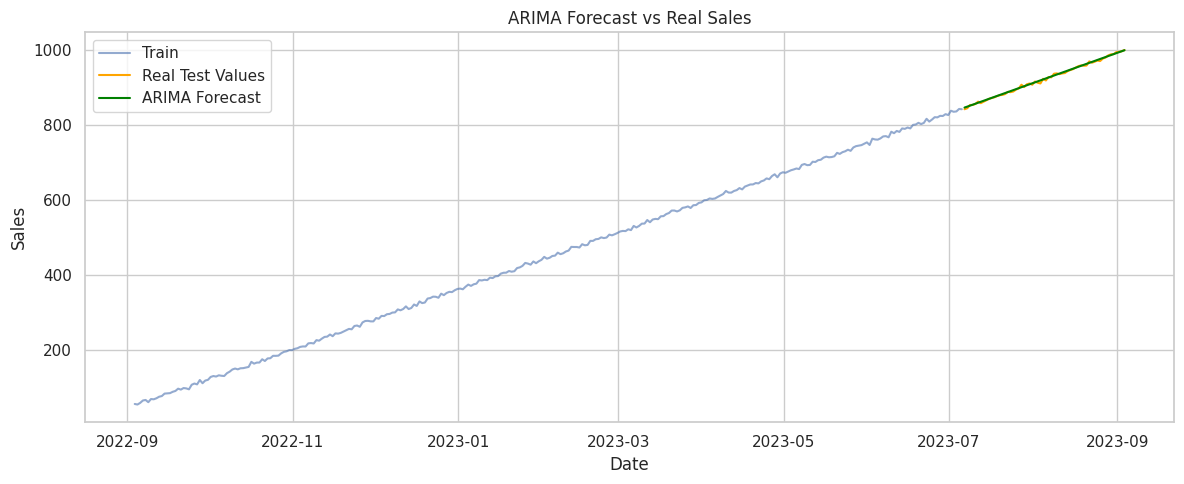

In [17]:
plt.figure(figsize=(12, 5))

sns.lineplot(x=train.index, y=train.values, label="Train", alpha=0.6)
sns.lineplot(x=test.index, y=test.values, label="Real Test Values", color="orange")
sns.lineplot(x=forecast.index, y=forecast.values, label="ARIMA Forecast", color="green")

plt.title("ARIMA Forecast vs Real Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.show()

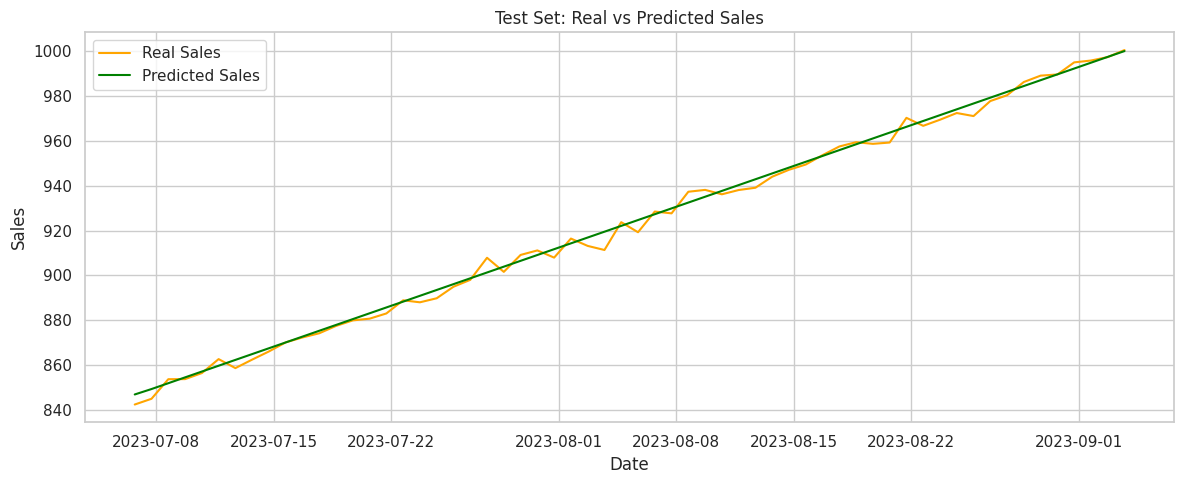

In [18]:
plt.figure(figsize=(12, 5))

sns.lineplot(x=test.index, y=test.values, label="Real Sales", color="orange")
sns.lineplot(x=forecast.index, y=forecast.values, label="Predicted Sales", color="green")

plt.title("Test Set: Real vs Predicted Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = np.mean(np.abs((test - forecast) / test)) * 100

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

MAE: 2.27
RMSE: 2.82
MAPE: 0.25%


In [20]:
import os

os.makedirs("models", exist_ok=True)

joblib.dump(arima_model, "models/arima_sales_model.pkl")

['models/arima_sales_model.pkl']

In [21]:
os.listdir("models")

['arima_sales_model.pkl']